In [25]:
import torch
print(torch.__version__)

2.8.0+cu126


In [26]:
# if this is the first time running, please install PyTorch Geometric
# may need to modify the version according to pytorch version
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.8.0+cu126.html


!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

In [28]:
# df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
# print(df.columns.tolist())

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel("/content/drive/MyDrive/BT4222/data/Main_Data_Bank_new.xlsx")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# df = df.drop(columns=['Bankkunde (1/0)','SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET','BANK WALLET I MNOK', 'ID NR (anonymisert dummy)'])
df = df.drop(columns=['Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET', 'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)','Tilskudd i USD', 'Total Production Value(NOK)', 'Subsidy Dependency Ratio', 'Bransje'])
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^0-9A-Za-z_]", "", regex=True)


for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})


target_col = 'NY_tilskuddskategori'
df = df.dropna(subset=[target_col])

le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])


['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']


/tmp/ipython-input-2865862665.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})


In [30]:
def generate_embeddings(df, prod_col='PRODUKSJON', region_cols=['Kommune', 'Fylke'],
                        prod_dim=16, region_dim=16):
    df = df.copy()

    df[prod_col + '_list'] = df[prod_col].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])
    mlb = MultiLabelBinarizer()
    prod_encoded = pd.DataFrame(mlb.fit_transform(df[prod_col + '_list']),
                                columns=mlb.classes_,
                                index=df.index)

    prod_svd = TruncatedSVD(n_components=prod_dim, random_state=42)
    prod_emb = prod_svd.fit_transform(prod_encoded)
    prod_emb_df = pd.DataFrame(prod_emb, columns=[f'PROD_emb_{i}' for i in range(prod_dim)],
                               index=df.index)

    df = pd.concat([df, prod_emb_df], axis=1)
    df = df.drop(columns=[prod_col, prod_col + '_list'])

    df_region = pd.get_dummies(df[region_cols], drop_first=True)

    region_svd = TruncatedSVD(n_components=region_dim, random_state=42)
    region_emb = region_svd.fit_transform(df_region)
    region_emb_df = pd.DataFrame(region_emb, columns=[f'REGION_emb_{i}' for i in range(region_dim)],
                                 index=df.index)

    df = pd.concat([df, region_emb_df], axis=1)
    df = df.drop(columns=region_cols)

    return df

In [31]:
region_cols = ['Kommune', 'Fylke']
df = generate_embeddings(df, prod_col='PRODUKSJON', region_cols=region_cols,
                         prod_dim=16, region_dim=16)

print(df.columns.tolist())

print(f"target '{target_col}'：")
print(df[target_col].value_counts())

['NY_tilskuddskategori', 'Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'Subsidy_Zone', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PR

In [32]:
# agri_features = [
# 'Geit_dyr', 'Gress_dekar', 'Korn_dekar', 'Melk_dyr', 'Sau_dyr', 'Storfe_dyr']

# we are choosing features to construct the graph, we try to select some important agri features)
# gnn_features = ['Kompleks_produksjon_10', 'NY_KOMMUNESCORE', 'NY_KOMMUNESKRE_FRITID', 'Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr', 'ENG_janei', 'INNSKUDD_janei', 'BANK_WALLET_I_MNOK', 'Kundelnnsomhet_Lnnsomhet_Bankr_i_Norge', 'LocationLeverage_Mismatch_Score', 'LoantoProductionValue_Ratio', 'Production_Concentration_Index', 'PROD_emb_0', 'PROD_emb_1', 'PROD_emb_2', 'PROD_emb_3', 'PROD_emb_4', 'PROD_emb_5', 'PROD_emb_6', 'PROD_emb_7', 'PROD_emb_8', 'PROD_emb_9', 'PROD_emb_10', 'PROD_emb_11', 'PROD_emb_12', 'PROD_emb_13', 'PROD_emb_14', 'PROD_emb_15', 'REGION_emb_0', 'REGION_emb_1', 'REGION_emb_2', 'REGION_emb_3', 'REGION_emb_4', 'REGION_emb_5', 'REGION_emb_6', 'REGION_emb_7', 'REGION_emb_8', 'REGION_emb_9', 'REGION_emb_10', 'REGION_emb_11', 'REGION_emb_12', 'REGION_emb_13', 'REGION_emb_14', 'REGION_emb_15']
gnn_features = ['Andre_dyr', 'Annet_fjrfe', 'Br', 'Bier', 'Blomster', 'Drivhus', 'Drivhus_kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grnt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg_av_fr', 'Sau', 'Storfe', 'kologisk', 'Annet', 'Ingen', 'Produkiv_skog', 'Annet_fjrfe_dyr', 'Br_dekar', 'Egg_verpehns', 'Frukt_dekar', 'Geit_dyr', 'Gress_dekar', 'Gris_dyr', 'Grnt_dekar', 'Hest_dyr', 'Korn_dekar', 'Kylling_dyr', 'Melk_dyr', 'Potet_dekar', 'Sau_dyr', 'Storfe_dyr']
df = df.dropna(subset=gnn_features + [target_col])
X_graph = df[gnn_features].values
y = df[target_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_graph)
# important features and their weights
important_features = {
    'Korn_dekar': 3.0,
    'Gress_dekar': 2.5,
    'Sau_dyr': 2.0,
    'Storfe_dyr': 1.8,
    'Melk_dyr': 1.5
}
for feat, w in important_features.items():
    if feat in gnn_features:
        idx = gnn_features.index(feat)
        X_scaled[:, idx] *= w

In [33]:
k = 250
# if the similarity is higher than threshold, we add an edge
threshold = 0.8
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# calculate cosine similarities
similarities = 1 - distances
n = X_scaled.shape[0]
A = lil_matrix((n, n))

for i in range(n):
    for j, sim in zip(indices[i][1:], similarities[i][1:]):
        if sim > threshold:
            A[i, j] = 1
            A[j, i] = 1
    if A[i].nnz == 0:
        j = indices[i][1]
        A[i, j] = 1
        A[j, i] = 1

In [34]:
degrees = np.array(A.sum(axis=1)).flatten()

print("Degree of each node:", degrees)
print("Average degree:", degrees.mean())
print("Standard deviation of degree:", degrees.std())
print("Median degree:", np.median(degrees))
print("Minimum degree:", degrees.min())
print("Maximum degree:", degrees.max())

Degree of each node: [428. 393. 334. ... 264. 425. 375.]
Average degree: 278.2889104795833
Standard deviation of degree: 98.48728491302693
Median degree: 288.0
Minimum degree: 1.0
Maximum degree: 567.0


In [35]:
edge_index, edge_attr = from_scipy_sparse_matrix(A)

data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=edge_index,
    y=torch.tensor(y, dtype=torch.float)
)


In [36]:
print(data)
print(f"nodes：{data.num_nodes}")
print(f"edges：{data.num_edges}")

Data(x=[37053, 43], edge_index=[2, 10311439], y=[37053])
nodes：37053
edges：10311439


In [37]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGEModel(in_channels=X_graph.shape[1], hidden=256, out_channels=4)

In [38]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


model.eval()
with torch.no_grad():
    embeddings = model(X_tensor, edge_index_tensor).numpy()
for i in range(embeddings.shape[1]):
    df[f"gnn_emb_{i}"] = embeddings[:, i]

/tmp/ipython-input-2714791679.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index_tensor = torch.tensor(edge_index, dtype=torch.long)  # [2, num_edges]


Train shape: (28850, 90), Test shape: (7213, 90)
Class distribution:
NY_tilskuddskategori
2    0.340737
1    0.240745
3    0.240385
0    0.178133
Name: proportion, dtype: float64 


=== Random Forest Model ===
✅ Random Forest Evaluation:
Accuracy: 0.884098156107029
ROC AUC: 0.981768291665878

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1285
           1       0.85      0.86      0.86      1736
           2       0.88      0.89      0.88      2458
           3       0.91      0.89      0.90      1734

    accuracy                           0.88      7213
   macro avg       0.89      0.88      0.89      7213
weighted avg       0.88      0.88      0.88      7213


=== Confusion Matrix ===


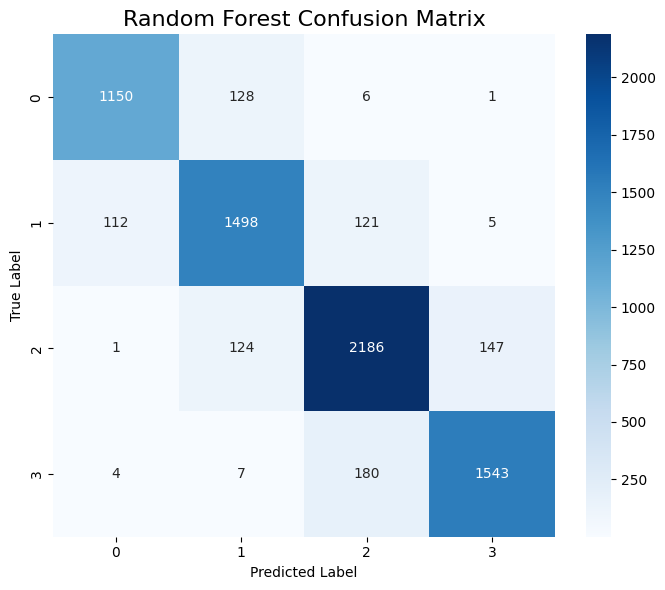


=== Feature Importance Analysis ===
Top 20 Important Features:
                           Feature  Importance
36                     Gress_dekar    0.078026
89                       gnn_emb_3    0.074415
40                      Korn_dekar    0.055405
45                      Storfe_dyr    0.053186
87                       gnn_emb_1    0.049659
44                         Sau_dyr    0.049110
88                       gnn_emb_2    0.041812
52  Production_Concentration_Index    0.041570
42                        Melk_dyr    0.039580
86                       gnn_emb_0    0.037535
54                      PROD_emb_0    0.033866
26                          Storfe    0.029865
56                      PROD_emb_2    0.028901
57                      PROD_emb_3    0.026111
66                     PROD_emb_12    0.021064
0           Kompleks_produksjon_10    0.021028
59                      PROD_emb_5    0.020762
21                            Melk    0.020093
61                      PROD_emb_7    0.019

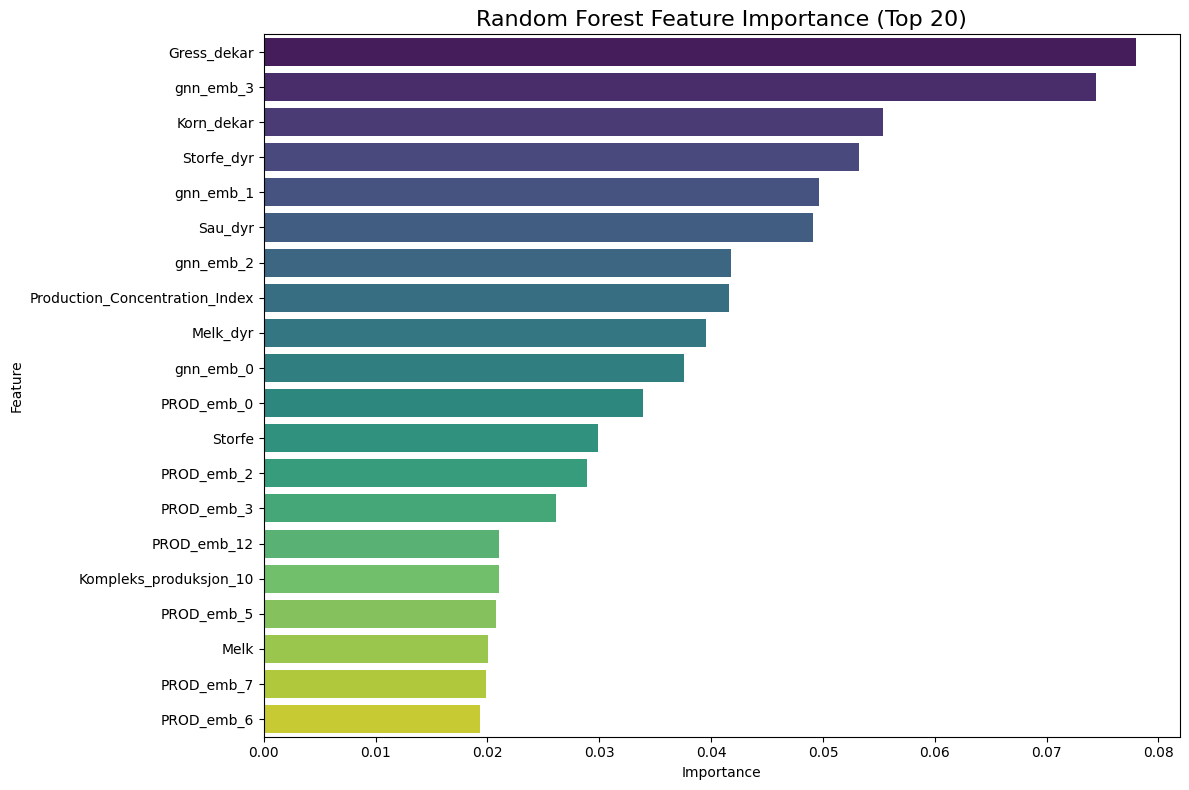

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report, confusion_matrix
)

# --- 1. Prepare data ---
target_col = 'NY_tilskuddskategori'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# Drop rows with NaN in features or target
X = X.dropna()
y = y.loc[X.index]

# --- 2. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Class distribution:")
print(y.value_counts(normalize=True), "\n")

# --- 3 Random Forest baseline ---
print("\n=== Random Forest Model ===")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)

print("✅ Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
try:
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')
    print("ROC AUC:", auc_rf)
except:
    print("ROC AUC could not be computed (too many or imbalanced classes)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# --- 4. Confusion Matrix ---
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- 5. Feature Importance ---
print("\n=== Feature Importance Analysis ===")
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Important Features:")
print(importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importances.head(20),
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title('Random Forest Feature Importance (Top 20)', fontsize=16)
plt.tight_layout()
plt.show()
